In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False 
from sklearn.metrics import mean_squared_error, mean_squared_log_error
import numpy as np

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f'训练集：{train_df.shape}')
print(f'测试集：{test_df.shape}')

train_df.head()

训练集：(750000, 9)
测试集：(250000, 8)


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [3]:
print(train_df.info())
print('############################')
print(train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB
None
############################
id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64


In [19]:
train_df.describe()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,0.499039,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,0.499999,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,0.000000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,0.000000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,1.000000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,1.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


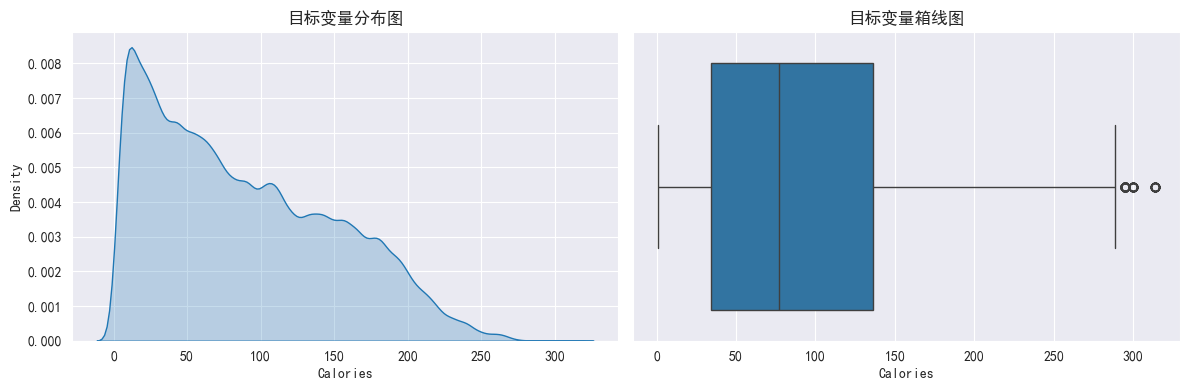

In [4]:
# EDA
fig, ax = plt.subplots(1,2,figsize=(12,4))
sns.kdeplot(data=train_df, x='Calories', ax=ax[0], fill=True)
ax[0].set_title('目标变量分布图')
sns.boxplot(data=train_df, x='Calories', ax=ax[1])
ax[1].set_title('目标变量箱线图')
plt.tight_layout()
plt.show()

数据存在右偏，有部分异常值

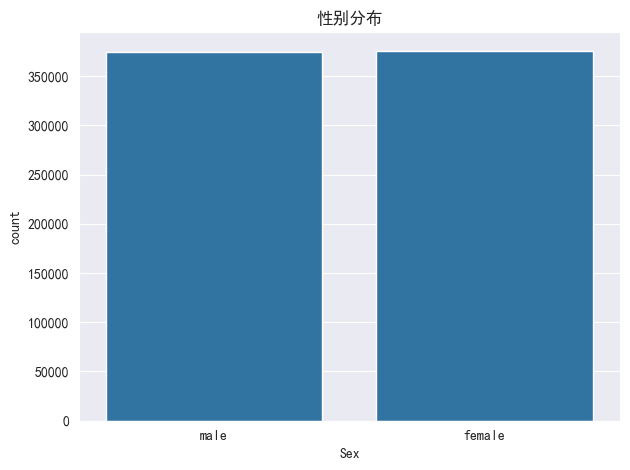

In [5]:
sns.countplot(x='Sex', data=train_df)
plt.title('性别分布')
plt.tight_layout()
plt.show()

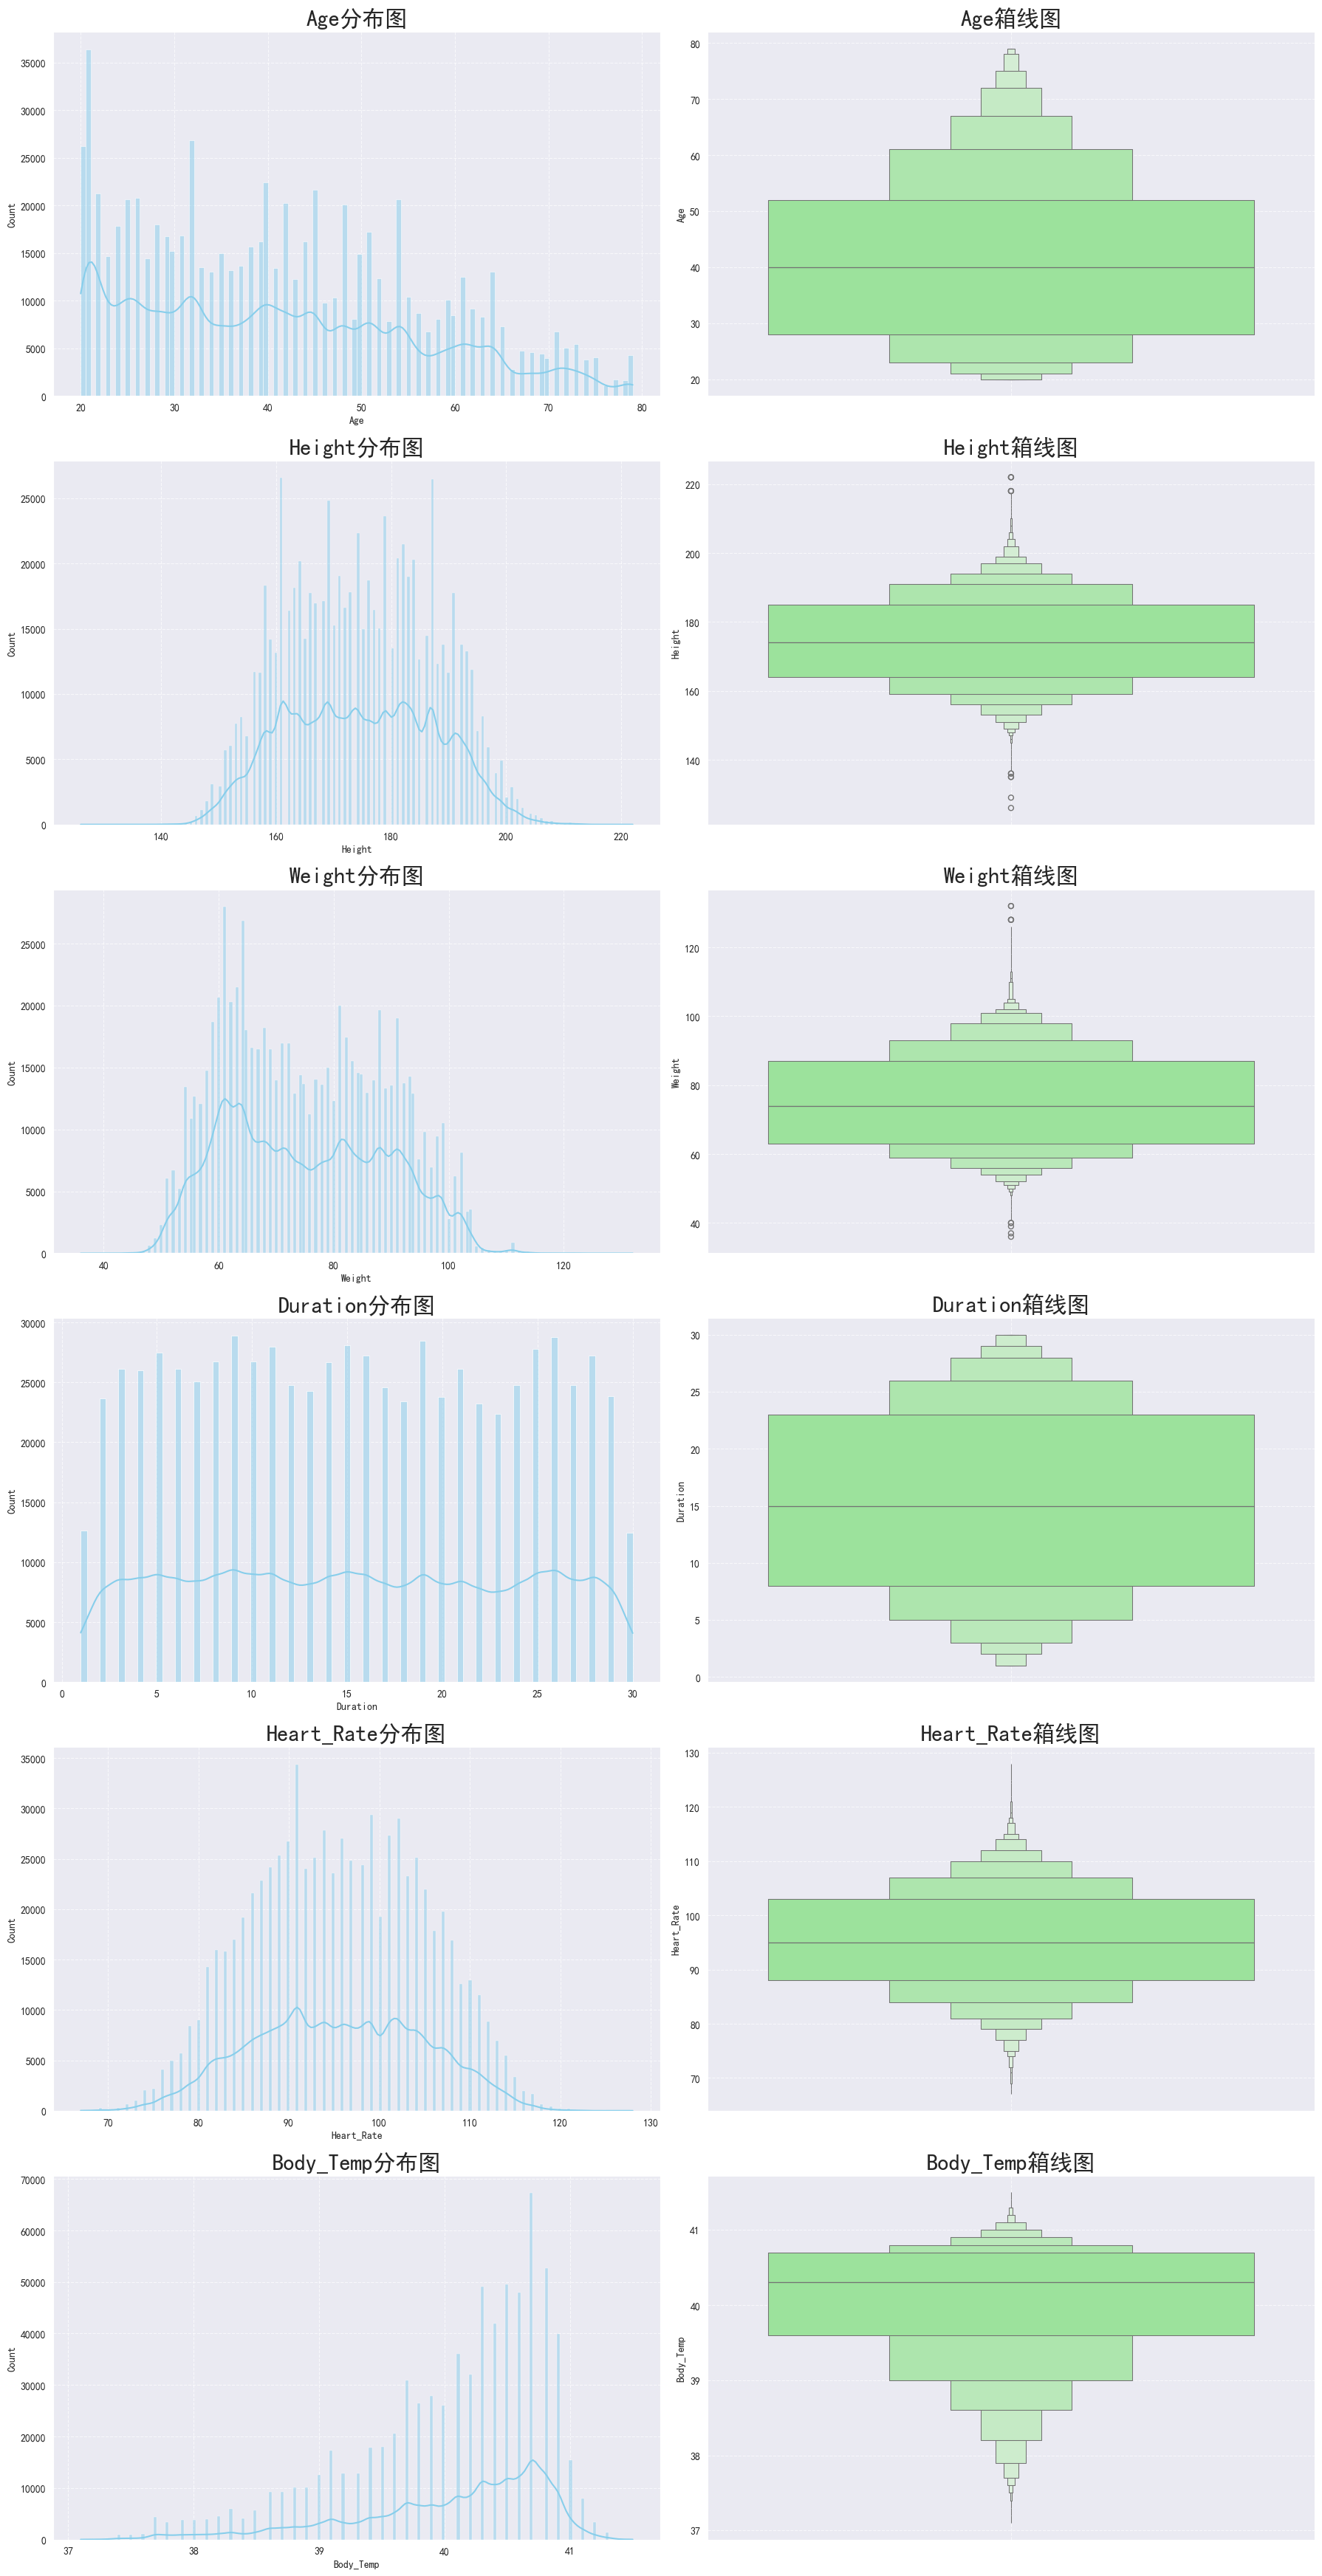

In [6]:
# 单变量分布
col = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

fig, axes = plt.subplots(len(col), 2, figsize=(18, 35))
for i, col in enumerate(col):
    sns.histplot(train_df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col}分布图', fontsize=22)
    axes[i, 0].grid(True, linestyle='--', alpha=0.7)
    
    sns.boxenplot(train_df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'{col}箱线图', fontsize=22)
    axes[i, 1].grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\79250\AppData\Local\Temp\ipykernel_11400\2261644876.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


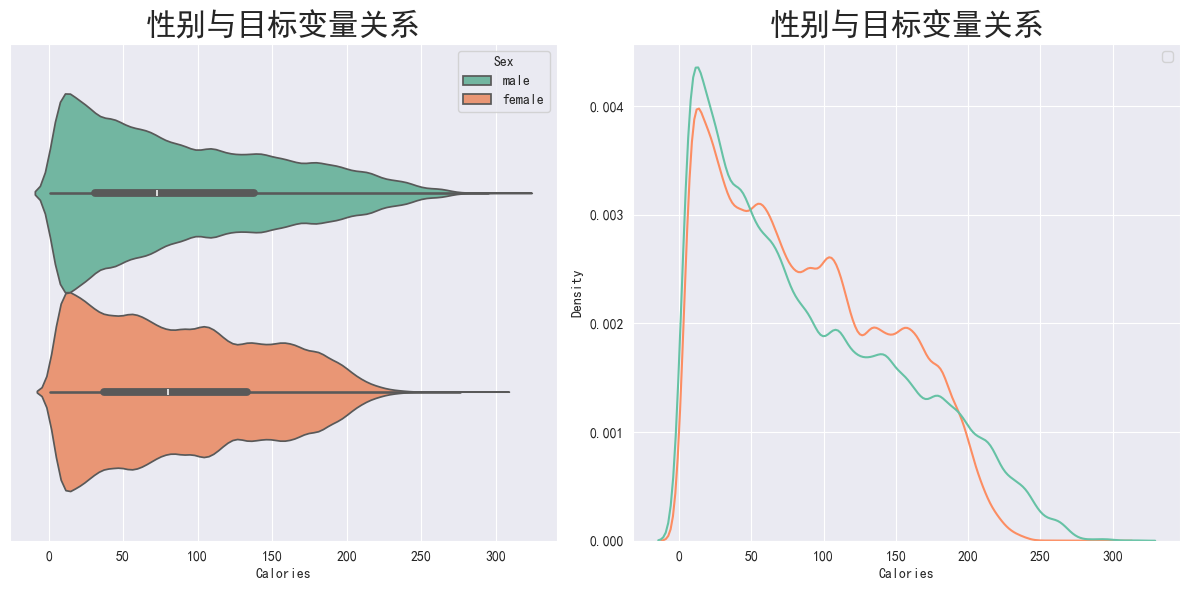

In [7]:
# 多变量
cat_col = ['Sex']
fig, ax = plt.subplots(1 ,2, figsize=(12, 6))
sns.violinplot(x='Calories', hue='Sex', data=train_df, ax=ax[0], palette='Set2')
ax[0].set_title('性别与目标变量关系', fontsize=22)

sns.kdeplot( x='Calories', hue='Sex', data=train_df, ax=ax[1], palette='Set2')
ax[1].set_title('性别与目标变量关系', fontsize=22)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# encoding Onehot_Encoding
train_df['Sex'] = train_df['Sex'].map({'female': 0, 'male': 1})
test_df['Sex'] = test_df['Sex'].map({'female': 0, 'male': 1})

In [9]:
train_df

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,1,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,0,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,0,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,1,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,0,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...,...
749995,749995,1,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,749996,0,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,749997,1,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,749998,1,45,182.0,91.0,17.0,102.0,40.3,109.0


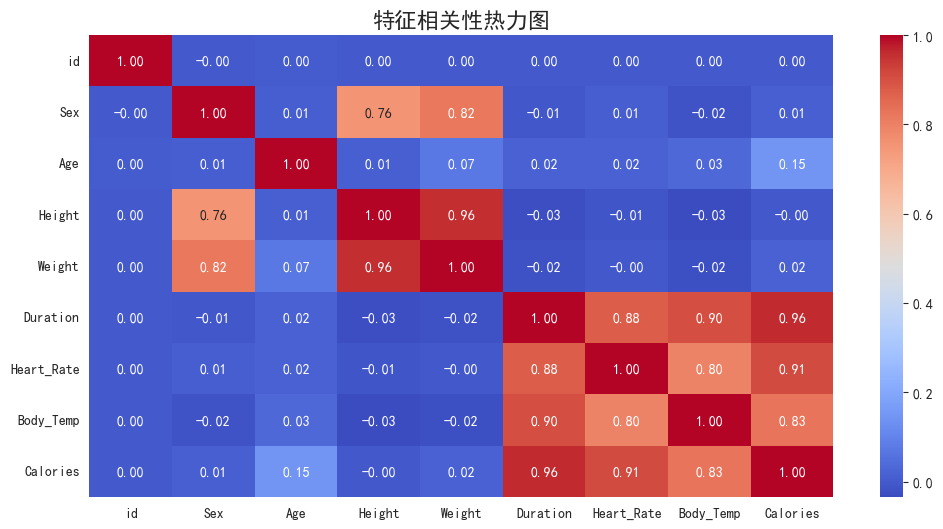

In [10]:
# heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('特征相关性热力图', fontsize=16)
plt.show()

In [11]:
# 相关系数大于0.1的
feature = ['Age', 'Duration', 'Heart_Rate', 'Body_Temp']
X = train_df[feature]
y = train_df.Calories
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [20]:
score = {}
# xgb
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
score['xgb'] = np.sqrt(mean_squared_log_error(y_test, y_pred))
# lgb
lgb_model = LGBMRegressor()
lgb_model.fit(X_train, y_train)
y_pred = lgb_model.predict(X_test)
score['lgb'] = np.sqrt(mean_squared_log_error(y_test, y_pred))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001530 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 198
[LightGBM] [Info] Number of data points in the train set: 562500, number of used features: 4
[LightGBM] [Info] Start training from score 88.314940


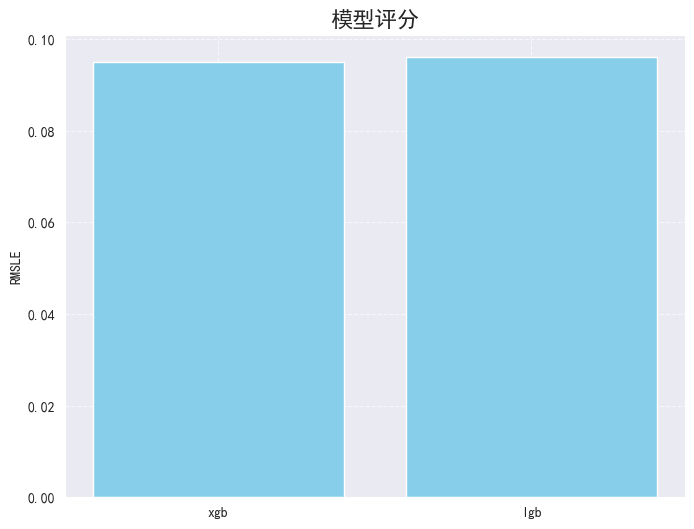

In [21]:
plt.figure(figsize=(8, 6))
plt.bar(score.keys(), score.values(), color='skyblue')
plt.title('模型评分', fontsize=16)
plt.ylabel('RMSLE')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [22]:
score

{'xgb': 0.09500292567157083, 'lgb': 0.09599744143089875}

In [31]:
pred = xgb_model.predict(test_df[feature])
pred[pred < 0] = 0 
sub = pd.DataFrame({
    'id':test_df.id,
    'Calories':pred
})
sub.to_csv('submission.csv', index=False)

In [32]:
sub.min()

id          750000.0
Calories         0.0
dtype: float64